# MES MACD mean-reversion, 60-minute bars (Tradovate exchange)

A third mean-reversion construction, after VWAP deviation-band (decisively
negative) and Bollinger Band (this program's strongest walk-forward-
confirmed result, MES/MNQ 30m). This one fades an extreme MACD histogram
reading instead of an extreme price level -- the histogram (MACD line minus
its own signal line) isn't naturally bounded the way a price-vs-band
distance is, so "extreme" is defined relative to the histogram's own rolling
mean/std (a z-score band), not a fixed threshold.

**Mechanism** (`MacdMeanReversionStrategy`): enters short when the histogram
reaches or exceeds `rolling_mean + entry_std * rolling_std` (unusually
strong bullish momentum -- expecting reversion down), long at the symmetric
lower band (unusually strong bearish momentum -- expecting reversion up),
filled at that bar's close (the histogram is only known at bar close, not an
intrabar-touchable price level). Fixed fractional-distance stop-loss/
take-profit, same convention as `BollingerMeanReversionStrategy`.

**Also testing KAMA as the underlying moving average** (`Indicators.macd_
kama`, new): Kaufman's Adaptive Moving Average tracks fast during clean
trends and flattens during chop, so a KAMA-based MACD should react
differently (likely less whipsaw-prone) than the standard EMA-based one --
included as a first-class grid dimension (`ma_type`) rather than assumed to
be better or worse.

**Plan**: Phase 1 grids MACD parameters (several canonical (fast, slow,
signal) triples) x `ma_type` (ema/kama), fixed `entry_std`/placeholder SL-TP.
Phase 2 grids `entry_std` x `sl_percent` on the winner (`tp_percent` fixed).
Then direction comparison, then holdout, then walk-forward if promising --
same escalating-refinement discipline as every other notebook in this
pipeline.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import MacdMeanReversionStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 60
UNIT_OF_TIME = "minute"

data_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(data_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 42240  span: 2019-05-05 22:59:59.999000 -> 2026-07-12 23:59:59.999000


## Phase 1: grid MACD parameters x ma_type (ema/kama), direction=both

`entry_std=2.0`, `rolling_lookback=100`, placeholder `sl_percent=0.01`/
`tp_percent=0.01` fixed for this pass -- tuned properly in Phase 2.


In [3]:
MACD_PARAM_CANDIDATES = [(5, 13, 5), (8, 17, 9), (12, 26, 9), (19, 39, 9)]
MA_TYPE_CANDIDATES = ["ema", "kama"]
ROLLING_LOOKBACK = 100
PLACEHOLDER_ENTRY_STD = 2.0
PLACEHOLDER_SL_PERCENT = 0.01
PLACEHOLDER_TP_PERCENT = 0.01
DEPOSIT_USD = 50_000


def run_macd_mr_backtest(ohlc_slice: pd.DataFrame, fast: int, slow: int, signal: int, ma_type: str,
                          entry_std: float, sl_percent: float, tp_percent: float, key: str,
                          direction: StrategyDirection = StrategyDirection.both):
    if ma_type == "ema":
        _line, histogram, _signal = Indicators.macd(ohlc_slice, fast=fast, slow=slow, signal=signal)
    else:
        _line, histogram, _signal = Indicators.macd_kama(ohlc_slice, fast=fast, slow=slow, signal=signal)

    rolling_mean = histogram.rolling(ROLLING_LOOKBACK).mean()
    rolling_std = histogram.rolling(ROLLING_LOOKBACK).std()
    upper = rolling_mean + entry_std * rolling_std
    lower = rolling_mean - entry_std * rolling_std

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="macd_hist", df=histogram)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="hist_upper", df=upper)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="hist_lower", df=lower)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=MacdMeanReversionStrategy(
            key=key, market=market, symbol=SYMBOL, histogram_key="macd_hist", upper_key="hist_upper", lower_key="hist_lower",
            sl_percent=sl_percent, tp_percent=tp_percent, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


def _summarize(bt, drawdown_mw, **extra_cols):
    summary = bt.reporter.summary["algo"]
    total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
    row = {**extra_cols}
    row.update({
        "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
        "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
        "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
    })
    return row


grid1_rows = []
grid1_backtests = {}
_t0 = time.time()
for fast, slow, signal in MACD_PARAM_CANDIDATES:
    for ma_type in MA_TYPE_CANDIDATES:
        bt, drawdown_mw = run_macd_mr_backtest(ohlc, fast, slow, signal, ma_type, PLACEHOLDER_ENTRY_STD,
                                                  PLACEHOLDER_SL_PERCENT, PLACEHOLDER_TP_PERCENT,
                                                  key=f"MACDMR_ind_{fast}_{slow}_{signal}_{ma_type}")
        grid1_backtests[(fast, slow, signal, ma_type)] = (bt, drawdown_mw)
        grid1_rows.append(_summarize(bt, drawdown_mw, macd_params=f"{fast}/{slow}/{signal}",
                                       fast=fast, slow=slow, signal=signal, ma_type=ma_type))
    print(f"macd_params={fast}/{slow}/{signal} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid1_results = pd.DataFrame(grid1_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 1 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid1_results[["macd_params", "ma_type", "net_return_percent", "sharpe_ratio", "max_drawdown_percent",
                       "closed_trades", "win_rate_percent", "dollar_profit_factor", "account_failed"]].to_string())


macd_params=5/13/5 done, 4s elapsed


macd_params=8/17/9 done, 8s elapsed


macd_params=12/26/9 done, 13s elapsed


macd_params=19/39/9 done, 17s elapsed



phase 1 grid done in 17s

  macd_params ma_type  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  dollar_profit_factor  account_failed
0      8/17/9    kama           -3.231230     -0.017598              -18.4428          669.0         50.672646              1.005344           False
1      8/17/9     ema          -11.312010     -0.160546              -30.0457          610.0         49.672131              0.967591           False
2      5/13/5    kama          -25.455665     -0.376787              -28.2185          774.0         49.095607              0.925713           False
3      5/13/5     ema          -28.990380     -0.476416              -34.7846          694.0         48.703170              0.894179           False
4     19/39/9     ema          -31.122380     -0.631554              -35.0525          520.0         46.538462              0.840181           False
5     12/26/9    kama          -35.492450     -0.694885              -36.4153  

## Phase 2: grid entry_std x sl_percent on the best (macd_params, ma_type) combo

Holding the MACD shape fixed at Phase 1's winner, `tp_percent=0.01` fixed
(matching this pipeline's other mean-reversion winners), grids `entry_std`
(how extreme a histogram reading must be to trigger) x `sl_percent` directly.


In [4]:
best_row = grid1_results.iloc[0]
best_fast, best_slow, best_signal, best_ma_type = int(best_row["fast"]), int(best_row["slow"]), int(best_row["signal"]), best_row["ma_type"]
print(f"Phase 1 winner: fast={best_fast}, slow={best_slow}, signal={best_signal}, ma_type={best_ma_type}")

ENTRY_STD_CANDIDATES = [1.5, 2.0, 2.5, 3.0]
SL_PERCENT_CANDIDATES = [0.005, 0.01, 0.015, 0.02]
FIXED_TP_PERCENT = 0.01

grid2_rows = []
grid2_backtests = {}
_t0 = time.time()
for entry_std in ENTRY_STD_CANDIDATES:
    for sl_percent in SL_PERCENT_CANDIDATES:
        bt, drawdown_mw = run_macd_mr_backtest(ohlc, best_fast, best_slow, best_signal, best_ma_type,
                                                  entry_std, sl_percent, FIXED_TP_PERCENT,
                                                  key=f"MACDMR_band_{entry_std}_{sl_percent}")
        grid2_backtests[(entry_std, sl_percent)] = (bt, drawdown_mw)
        grid2_rows.append(_summarize(bt, drawdown_mw, entry_std=entry_std, sl_percent=sl_percent))
    print(f"entry_std={entry_std} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid2_results = pd.DataFrame(grid2_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 2 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid2_results.to_string())


Phase 1 winner: fast=8, slow=17, signal=9, ma_type=kama


entry_std=1.5 done, 13s elapsed


entry_std=2.0 done, 23s elapsed


entry_std=2.5 done, 32s elapsed


entry_std=3.0 done, 43s elapsed



phase 2 grid done in 43s

    entry_std  sl_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0         2.5       0.015            3.291852      0.081448              -14.3157          430.0             59.7         60.930233       1.052974               0.020529              1.031848           7.218302         1472.38           False
1         2.0       0.015            1.355845      0.053610              -19.9257          578.0             80.3         60.726644       1.044949               0.017501              1.020352           4.556218         1969.24           False
2         2.0       0.010           -3.231230     -0.017598              -18.4428          669.0             92.9         50.672646       1.038055               0.018666              1.005344           0.994911         2237.69           False
3

### Heatmaps: Sharpe ratio and net return across (entry_std, sl_percent)


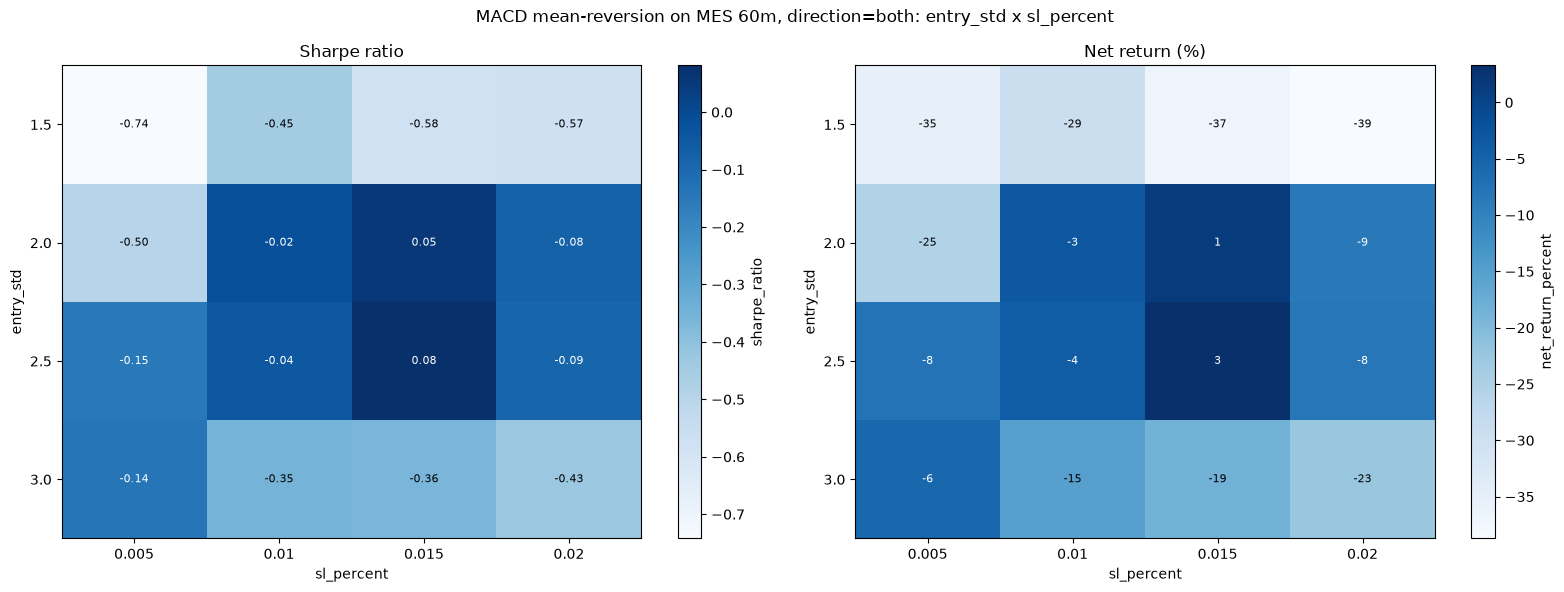

In [5]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str, xlabel: str, ylabel: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid2_results.pivot(index="entry_std", columns="sl_percent", values="sharpe_ratio")
return_pivot = grid2_results.pivot(index="entry_std", columns="sl_percent", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f", "sl_percent", "entry_std")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f", "sl_percent", "entry_std")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle("MACD mean-reversion on MES 60m, direction=both: entry_std x sl_percent")
fig.tight_layout()
plt.show()


## Detailed report for the overall best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
best (macd_params, ma_type, entry_std, sl_percent) combo across both grids.


Best combo: 8/17/9 (kama), entry_std=2.5, sl_percent=0.015, tp_percent=0.01
Candles Processed: 42239
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,0.0814,-0.5341,0.1463,-0.4417,0.9347,0.5349,-0.9409,-0.4281,1.3425,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.1147,-0.7390,0.2102,-0.6321,1.3697,0.7694,-1.1949,-0.5668,1.9548,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,6.1060,6.3399,7.2388,5.9840,7.5119,5.6116,5.0042,4.7630,5.8063,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,0.4514,-5.0625,1.1656,-4.0157,10.2827,4.2180,-6.7802,-3.0777,11.7430,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.0315,-0.6417,0.1623,-0.4142,0.8809,0.6091,-0.9848,-0.6017,3.5401,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,0.2299,-0.4257,0.1623,-0.4130,0.8784,0.6074,-0.9848,-0.6000,1.8132,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-14.3157,-7.8895,-7.1799,-9.6961,-11.6728,-6.9255,-6.8852,-5.1152,-3.3171,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,944,188,151,271,193,268,365,330,85,719,How long it took to recover the loss. Shorter is better.
ulcer_index,6.7816,4.8283,3.4948,5.0866,5.5463,2.8352,4.4171,2.9195,1.5543,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.6607,-0.6661,-0.8576,-0.6382,-0.8839,-0.5877,-0.6244,-0.5637,-0.5731,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


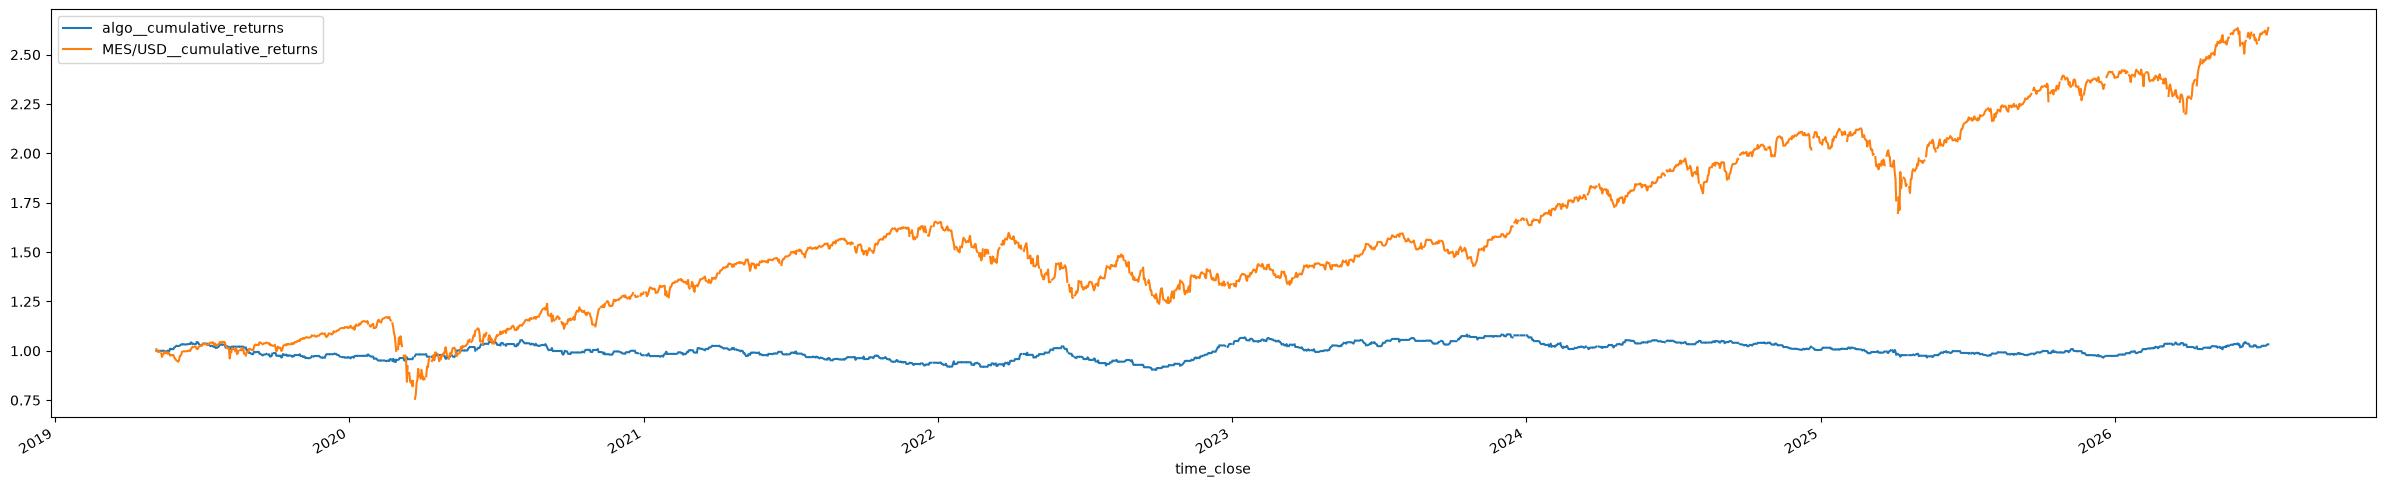

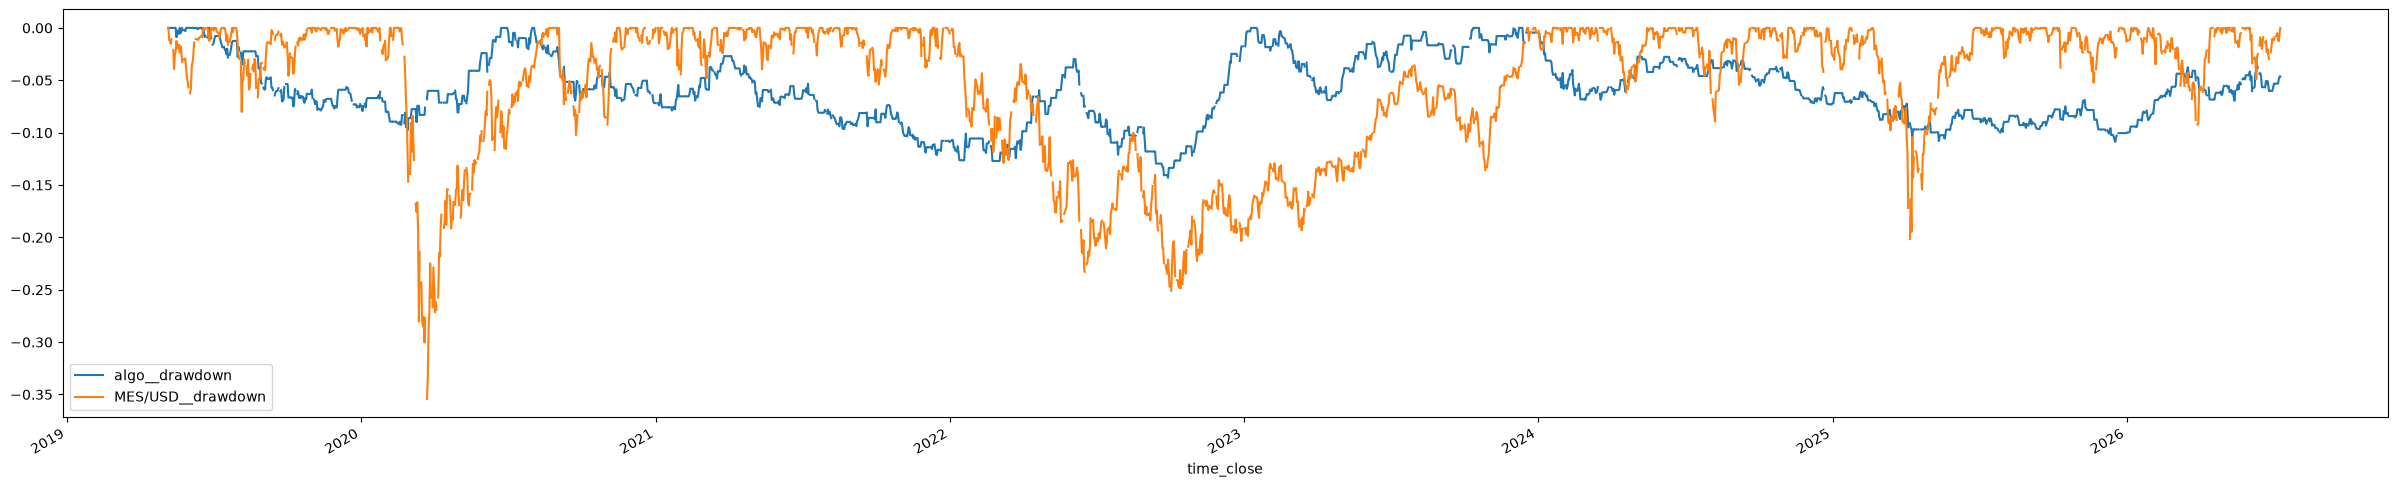

In [6]:
best_entry_std, best_sl_percent = grid2_results.iloc[0][["entry_std", "sl_percent"]]
best_entry_std = float(best_entry_std)
best_sl_percent = float(best_sl_percent)
print(f"Best combo: {best_fast}/{best_slow}/{best_signal} ({best_ma_type}), entry_std={best_entry_std}, sl_percent={best_sl_percent}, tp_percent={FIXED_TP_PERCENT}")
best_backtest, best_drawdown_mw = grid2_backtests[(best_entry_std, best_sl_percent)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Direction comparison: both vs. long-only vs. short-only

Holding (macd_params, ma_type, entry_std, sl_percent, tp_percent) fixed at
the overall best combo, re-runs with `direction=long` and `direction=short`.


In [7]:
direction_rows = []
direction_backtests = {}
for direction in [StrategyDirection.both, StrategyDirection.long, StrategyDirection.short]:
    bt, drawdown_mw = run_macd_mr_backtest(ohlc, best_fast, best_slow, best_signal, best_ma_type,
                                              best_entry_std, best_sl_percent, FIXED_TP_PERCENT,
                                              key=f"MACDMR_dir_{direction.value}", direction=direction)
    direction_backtests[direction] = (bt, drawdown_mw)
    direction_rows.append({"direction": direction.value, **_summarize(bt, drawdown_mw)})

direction_df = pd.DataFrame(direction_rows).set_index("direction")
print(direction_df.to_string())


           net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
direction                                                                                                                                                                                                                         
both                 3.291852      0.081448              -14.3157          430.0             59.7         60.930233       1.052974               0.020529              1.031848           7.218302         1472.38           False
long                 5.120982      0.118973              -12.4406          315.0             43.8         61.904762       1.083333               0.031746              1.051158          11.454846         1059.24           False
short              -16.389468     -0.319219              -21.3796          281.0            

## Holdout check: does the best (combo, direction) survive a train/test split?

Uses whichever of both/long/short scored highest above.


In [8]:
best_direction_label = direction_df["sharpe_ratio"].idxmax()
best_direction = StrategyDirection(best_direction_label)
print(f"Best direction: {best_direction_label}")

split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_macd_mr_backtest(ohlc_slice, best_fast, best_slow, best_signal, best_ma_type,
                                              best_entry_std, best_sl_percent, FIXED_TP_PERCENT,
                                              key=f"MACDMR_holdout_{label}", direction=best_direction)
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


Best direction: long
train/test split at 2024-09-20 09:59:59.999000  (31680 train bars, 10560 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                        315         61.904762      0.039161        -0.053560        0.118973            5.120982              1.051158          11.454846              -12.4406           False
TRAIN (75%)                 236         61.440678      0.029536        -0.077568        0.064426            1.587777              1.030403           7.248391              -12.4406           False
TEST (last 25%, unseen)      77         63.636364      0.075100        -0.112629        0.357543            3.829640              1.149032          26.735065               -4.9455           False


## Findings

**Much weaker than 15m -- does not clear the bar for walk-forward.** Best
combo (`8/17/9`, **KAMA** this time -- unlike 15m where EMA won every
comparison, KAMA edges out EMA here, though only by beating a weak field):
FULL Sharpe (long) **0.119**, net return +5.1%, `dollar_profit_factor`
1.051 -- a thin edge.

**Direction comparison**: `long` (0.119) beats `both` (0.081) and `short`
(-0.319), same pattern as everywhere else, but the gap between long and both
is much smaller than 15m's, and the absolute level is far weaker.

**Holdout is decisively unpromising**: TRAIN `trade_sharpe_lb`=-0.078
(negative), TEST `trade_sharpe_lb`=-0.113 (also negative) -- neither window
clears zero, unlike 15m where TRAIN was clearly positive. This never reaches
the "promising, not yet confirmed" tier -- it's negative at both stages.

**Bottom line**: MACD mean-reversion is too weak on MES 1-hour bars to
justify walk-forward -- consistent with this pipeline's Bollinger mean-
reversion result, where 1-hour bars also underperformed 30-minute/15-minute
alternatives (thinner trade sample, noisier per-parameter estimates). Not
walk-forwarding this one.